============================================================\
**Notebook 01** : Data Preprocessing & Feature Engineering\
**Output** : processed_features.csv, X_train/test, y_train/test, scaler.pkl\
============================================================\

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [3]:

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# setting plot sizes globally
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 13

print('Imports and Configs successful')

Imports and Configs successful


In [4]:
print(os.listdir('../data/'))

['online-retail.xlsx']


---
### 1. Load Data

In [5]:
# Load the dataset — adjust path if needed
df = pd.read_excel('../data/online-retail.xlsx', dtype={'CustomerID': str}) # make customer id string

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(10)

Shape: (541909, 8)
Rows: 541,909  |  Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom


---
### 2. Basic Overview

In [6]:
# Column data types
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Basic Stats ===')
df.describe()

=== Data Types ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

=== Basic Stats ===


,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


The dataset contains 541,909 rows and 8 columns. Quantity and UnitPrice
contain negative values (min: -80,995 and -11,062) indicating cancellations and
returns that must be removed. InvoiceDate is correctly parsed as datetime.
CustomerID is stored as object (string), which is expected since we did in dataset loading.

In [7]:
print('=== Unique Value Counts ===')
for col in df.columns:
    print(f'{col:15s}: {df[col].nunique():>7,} unique values')

=== Unique Value Counts ===
InvoiceNo      :  25,900 unique values
StockCode      :   4,070 unique values
Description    :   4,223 unique values
Quantity       :     722 unique values
InvoiceDate    :  23,260 unique values
UnitPrice      :   1,630 unique values
CustomerID     :   4,372 unique values
Country        :      38 unique values


The dataset has **4,372 unique customers**, which is very well need for the future prediction

---
### 3. Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df)

             Missing Count  Missing %
CustomerID          135080      24.93
Description           1454       0.27
StockCode                0       0.00
InvoiceNo                0       0.00
Quantity                 0       0.00
InvoiceDate              0       0.00
UnitPrice                0       0.00
Country                  0       0.00


CustomerID has 135,080 missing values (24.93%), the most critical issue.
Since the model predicts repurchase per customer, rows without a CustomerID
cannot be tracked and must be dropped. Description has 1,454 missing (0.27%)
but is not used as a model feature, so it has no impact. All other columns
are complete. NEED TO DROP THE ROWS WITH MISSING VALUES IN THE PREPROCESSING STEP.

---
### 4. EDA - Distributions & Patterns

Normal invoices   : 532,621
Cancellations     : 9,288 (1.7%)


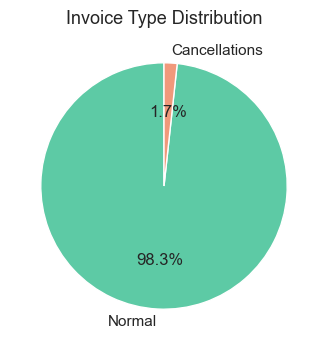

In [9]:
# Cancellations (InvoiceNo starting with 'C')
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
normal = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f'Normal invoices   : {len(normal):,}')
print(f'Cancellations     : {len(cancellations):,} ({len(cancellations)/len(df)*100:.1f}%)')

labels = ['Normal', 'Cancellations']
sizes  = [len(normal), len(cancellations)]
colors = ['#5DCAA5', '#F0997B']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Invoice Type Distribution')
plt.savefig('../outputs/invoice_type_pie.png', bbox_inches='tight')
plt.show()

Out of 541,909 transactions, 9,288 (1.7%) are cancellations identified by
InvoiceNo starting with `C`. These represent refunds, not real purchases,
and must be removed to avoid misleading the repurchase prediction model.

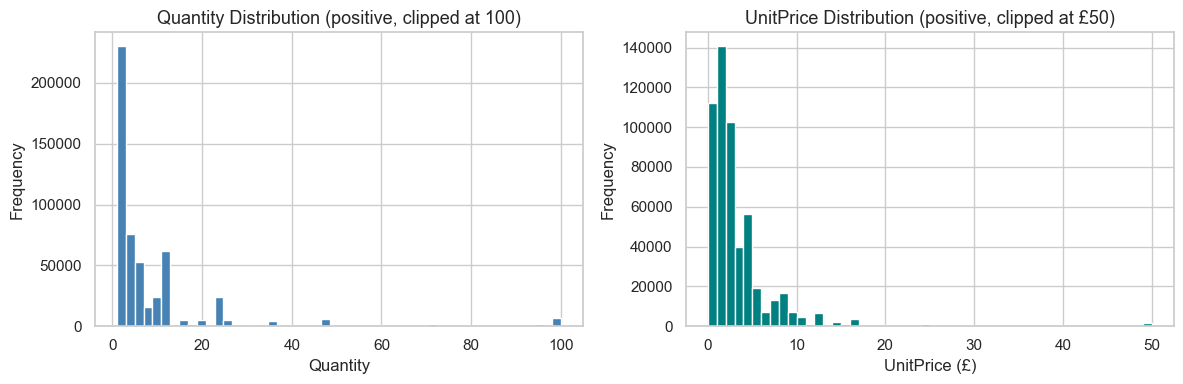

In [10]:
# Quantity and UnitPrice distributions (before cleaning)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Clip for readability
df[df['Quantity'] > 0]['Quantity'].clip(upper=100).plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Quantity Distribution (positive, clipped at 100)')
axes[0].set_xlabel('Quantity')

df[df['UnitPrice'] > 0]['UnitPrice'].clip(upper=50).plot(
    kind='hist', bins=50, ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('UnitPrice Distribution (positive, clipped at £50)')
axes[1].set_xlabel('UnitPrice (£)')

plt.tight_layout()
plt.savefig('../outputs/quantity_unitprice_hist.png', bbox_inches='tight')
plt.show()

Both distributions are heavily right-skewed. Most orders have a quantity
between 1–10 units and are priced under £10, indicating small retail purchases.
The long tails suggest outliers — bulk wholesale orders — which may need
capping during feature engineering. BULK PURCHASING IS NOT A DESIRED BEHAVIOUR. MAY BE REMOVED.

=== Orders per Customer ===
count    4339.000000
mean        4.271952
std         7.705493
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       210.000000
Name: InvoiceNo, dtype: float64

Customers with only 1 order : 1,494 (34.4%)
Customers with 2+ orders   : 2,845 (65.6%)


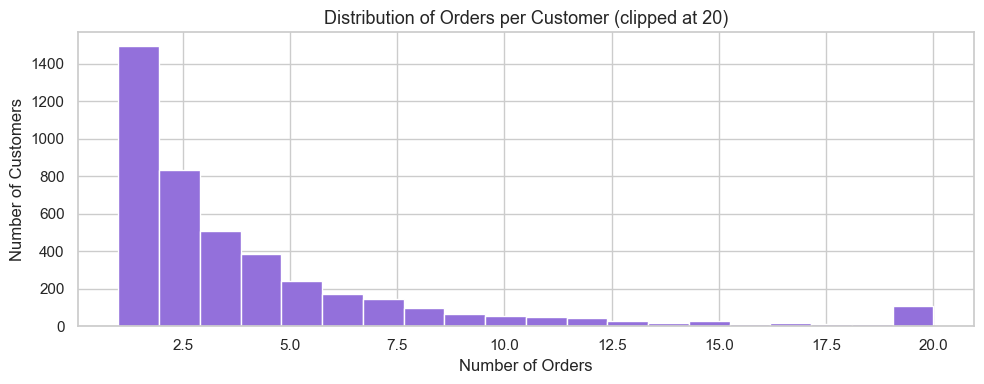

In [11]:
# Distribution of orders per customer
orders_per_customer = (
    df.dropna(subset=['CustomerID'])
    [~df['InvoiceNo'].astype(str).str.startswith('C')]
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
)

print('=== Orders per Customer ===')
print(orders_per_customer.describe())
print(f'\nCustomers with only 1 order : {(orders_per_customer == 1).sum():,} ({(orders_per_customer == 1).mean()*100:.1f}%)')
print(f'Customers with 2+ orders   : {(orders_per_customer >= 2).sum():,} ({(orders_per_customer >= 2).mean()*100:.1f}%)')

orders_per_customer.clip(upper=20).plot(
    kind='hist', bins=20, color='mediumpurple', edgecolor='white'
)
plt.title('Distribution of Orders per Customer (clipped at 20)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../outputs/orders_per_customer_hist.png', bbox_inches='tight')
plt.show()

The distribution is heavily right-skewed - the majority of customers placed
only 1–2 orders in the entire period. This directly implies class imbalance
in our target variable: most customers will have label `0` (will not repurchase
in 30 days), making it a challenging classification problem.

---
### 6. EDA - Sales Trends

In [12]:
# Parse dates for trend analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year']  = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


DATASET CONTAINS ONLINE RETAIL DATA FROM 2010 TO 2011, AROUND 1 YEAR OF DATA

---
### 7. Preprocessing - Clean the Data

In [13]:
# 1. Drop rows with no CustomerID (can't track customers)
df = df.dropna(subset=['CustomerID'])

In [14]:
# 2. Remove cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [15]:
# 3. Remove negative/zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [16]:
# 4. Convert CustomerID to string (it's treated as a label, not a number)
df['CustomerID'] = df['CustomerID'].astype(str)

In [17]:
# 5. Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [18]:
# 6. Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [19]:
print(f"Clean dataset shape: {df.shape}")
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Clean dataset shape: (397884, 13)
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


---
### 8. Feature Engineering